In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import csv
import os
import subprocess
from tqdm import tqdm_notebook
import pprint
import librosa
from IPython.display import clear_output
from scipy.ndimage import convolve
import music21
import madmom
from scipy.signal import convolve2d
from scipy.stats import linregress
from multiprocessing import Pool
import yaml
import pickle
import mido
from mido import MidiFile

from msmd.midi_parser import notes_to_onsets, FPS
from msmd.data_model.piece import Piece
from msmd.alignments import align_score_to_performance

In [5]:
DATA_ROOT_REAL = '../real_dataset'

In [76]:
pieces = glob.glob(os.path.join(DATA_ROOT_REAL, 'pickle', '*'))

In [90]:
def downsampleImage(strip, ratio):
    return np.array([[x[i] for i in range(len(x)) if i%ratio == 0] for x in strip])

def getMidiNoteEvents(midifile, fs = 100):
    mid = MidiFile(midifile)
    tempo = 500000 # default microseconds per beat
    curTimeSec = 0.0
    allEvents = []
    noteEvents = []
    
    for i, track in enumerate(mid.tracks):
        events_temp = []
        curTimeTick = 0
        for msg in track:
            curTimeTick += msg.time
            if msg.type == 'set_tempo':
                tempo = msg.tempo
                events_temp.append(('tempo',curTimeTick, tempo))
            if msg.type == 'note_on' and msg.velocity > 0:
                events_temp.append(('note',curTimeTick, msg.note))
            if msg.type == 'text' and '!!!END:' in msg.text: # ignore command messages that add time at end
                break 
        allEvents = allEvents + events_temp
    allEvents = sorted(allEvents, key=lambda x: x[1])
        
    # Convert accumulated time back to time difference
    allEvents_diff = []
    for i in range(len(allEvents)):
        if i == 0:
            allEvents_diff.append(allEvents[i])
        else:
            allEvents_diff.append((allEvents[i][0], allEvents[i][1]-allEvents[i-1][1], allEvents[i][2]))
    
    # Convert tick to second
    for event in allEvents_diff:
        curTimeSec += mido.tick2second(event[1], mid.ticks_per_beat, tempo)
        if event[0] == 'tempo':
            tempo = event[2]
        else:
            colIdx = np.int(np.round(curTimeSec * fs))
            noteEvents.append((colIdx, event[2]))
    return noteEvents

def calcErrorStats(errs_raw, tols, isSingle = False):
    if isSingle:
        errs = errs_raw
    else:
        errs = np.array([err for sublist in errs_raw for err in sublist])
    errs = errs[~np.isnan(errs)] # when beat is not annotated, value is nan
    errorRates = []
    for tol in tols:
        toAdd = np.sum(np.abs(errs) > tol) * 1.0 / len(errs)
        errorRates.append(toAdd)
    return errorRates

In [148]:
def processPiece(piece_idx, debug=False):
    piece = os.path.split(pieces[piece_idx])[1]

    # Load strips
    strips = None
    with open(os.path.join(DATA_ROOT_REAL, 'pickle', piece), 'rb') as f:
        strips = pickle.load(f)

    # Load sheet music annotation
    df = pd.read_csv(os.path.join(DATA_ROOT_REAL, 
                                  'sheet_annot', 
                                  '_'.join(piece.split('_')[:-1]) + '_beats.csv'))
    df = df[df['score'] == '_'.join(piece.split('_')[1:])]

    # Load wp
    dhyp = np.load(os.path.join(DATA_ROOT_REAL, 'output', piece, 'output.npy'))
    zeroPad = dhyp.item().get('zeroPad')
    timeMapping = dhyp.item().get('timeMapping')
    striplens = dhyp.item().get('striplens')
    wp = dhyp.item().get('wp')

    # sheet music ref
    striplens = [s.shape[1] for s in strips]
    pixelOffset = np.cumsum([0] + striplens)  # cumulative pixel offset for each strip
    stripsPerPage = [df.loc[df.page == i,'strip'].max() for i in range(df.page.max()+1) ]
    stripOffset = np.cumsum([0] + stripsPerPage)
    stripIdx = stripOffset[df.page] + df.strip - 1  # cumulative strip index
    hpixlocs = pixelOffset[stripIdx] + (df.hpixel  * 100 // 72)
    ref1 = hpixlocs

    # Load MIDI annotation
    annot_file = os.path.join(DATA_ROOT_REAL, 
                              'midi_annot', 
                              '_'.join(piece.split('_')[:-1]) + '.csv')

    midiFile = os.path.join(DATA_ROOT_REAL, 
                            'midi', 
                            '_'.join(piece.split('_')[:-1]) + '.mid')

    # find optimal fs
    fs = 100.0
    noteEvents = getMidiNoteEvents(midiFile, fs)
    striplen = np.sum([s.shape[1] for s in strips])
    fs = np.int(fs * striplen / noteEvents[-1][0]) # adjust to get equal lengths

    timeStamps = []
    with open(annot_file, newline='') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=',', quotechar='|')
        for row in spamreader:
            if row[0] != '-':
                timeStamps.append(float(row[0]))
            else:
                timeStamps.append(float('inf'))
    timeStamps = np.array(timeStamps)

    # convert to mapped frames
    frames = (timeStamps - timeStamps[0]) * fs
    mapped_frms = [i for i, elem in enumerate(timeMapping) if elem != -1]
    orig_frms = [elem for elem in timeMapping if elem != -1]
    orig_frms = np.array(orig_frms) - orig_frms[0]
    mapped_interp = np.interp(frames, orig_frms, mapped_frms)
    padded = mapped_interp + zeroPad

    sheet_ref_beats = hpixlocs
    midi_ref_beats = padded

    # calculate prediction errors [dtw]
    sheet_preds = wp[:,0]
    midi_preds = wp[:,1]
    hypFrames = np.interp(sheet_ref_beats, sheet_preds, midi_preds)
    hypPixels = np.interp(midi_ref_beats, midi_preds, sheet_preds)
    minLen = np.min((len(hypFrames), len(hypPixels)))
#     errsFrames = hypFrames[0:minLen] - midi_ref_beats[0:minLen]
#     errsTime = errsFrames * 1000.0 / fs  # in ms
    errsPixels = hypPixels[0:minLen] - sheet_ref_beats[0:minLen]    
    errorRate_dtw = calcErrorStats(errsPixels, range(3000), isSingle = True)
    
    # calculate prediction errors [global linear]
    sheet_preds = wp[[0,-1],0]
    midi_preds = wp[[0,-1],1]
    hypFrames = np.interp(sheet_ref_beats, sheet_preds, midi_preds)
    hypPixels = np.interp(midi_ref_beats, midi_preds, sheet_preds)
    minLen = np.min((len(hypFrames), len(hypPixels)))
#     errsFrames = hypFrames[0:minLen] - midi_ref_beats[0:minLen]
#     errsTime = errsFrames * 1000.0 / fs  # in ms
    errsPixels = hypPixels[0:minLen] - sheet_ref_beats[0:minLen]    
    errorRate_global_linear = calcErrorStats(errsPixels, range(3000), isSingle = True)
    
    plt.plot(errorRate_dtw, label='Ours')
    plt.plot(errorRate_global_linear, label='Global Linear')
    plt.title(piece)
    plt.ylim([0,1])
    plt.grid()
    plt.legend()
    plt.show()

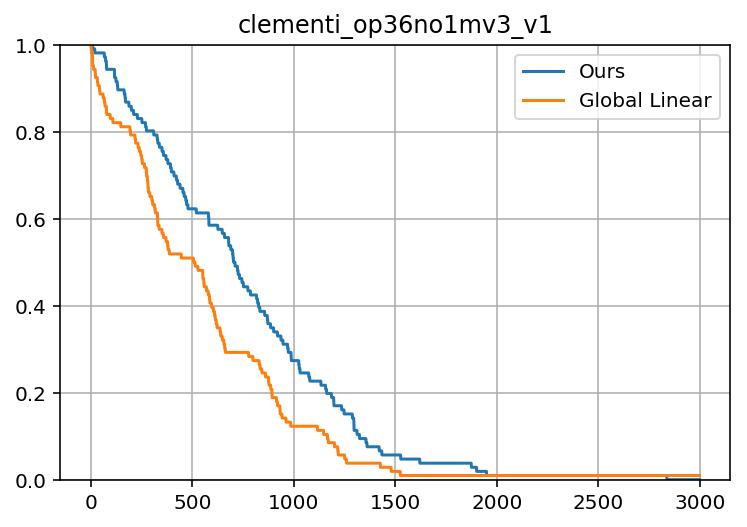

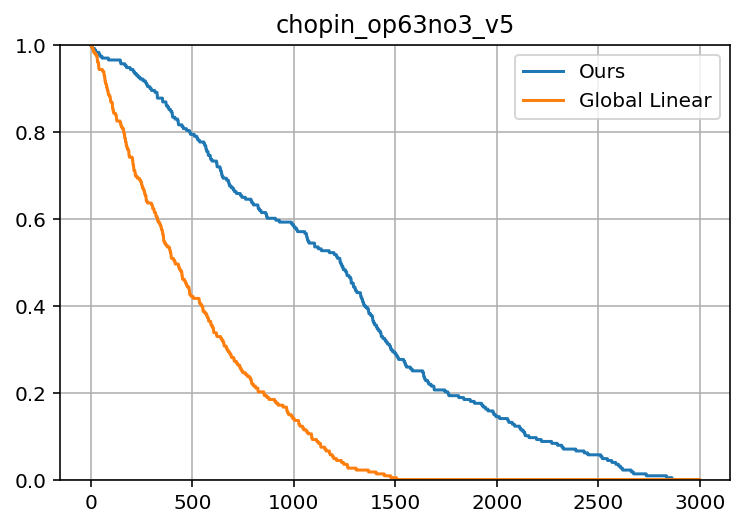

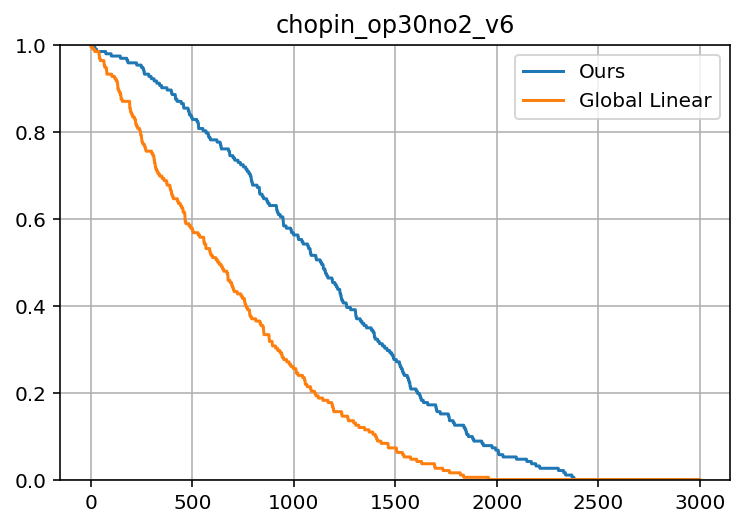

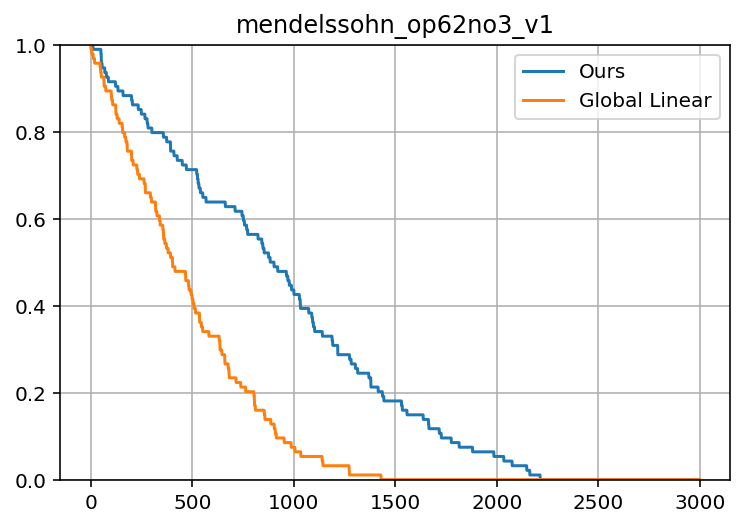

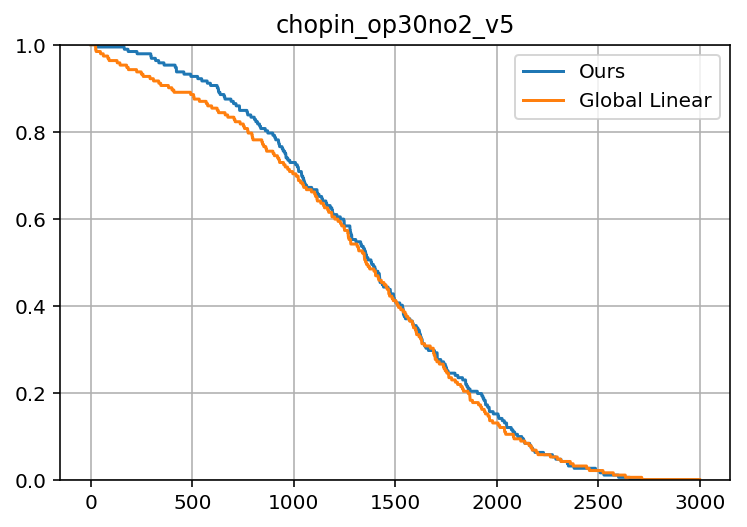

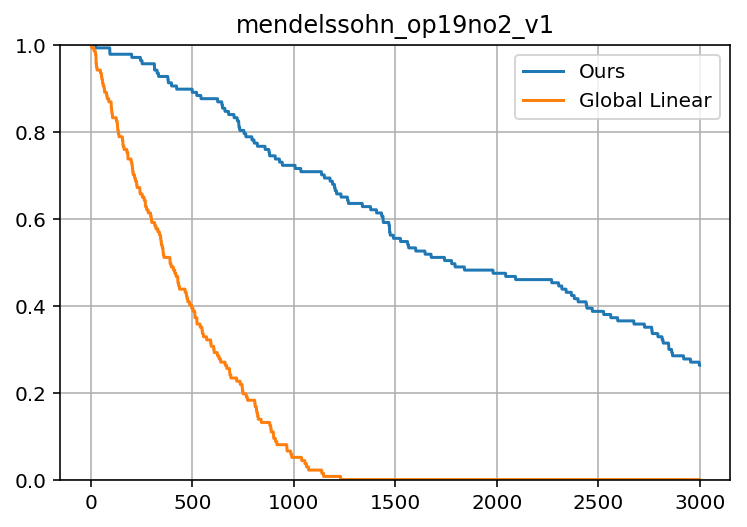

FileNotFoundError: [Errno 2] No such file or directory: '../real_dataset/output/brahms_op117no2_v3/output.npy'

In [150]:
for i in range(len(pieces)):
    processPiece(i, debug=True)

(0, 1)

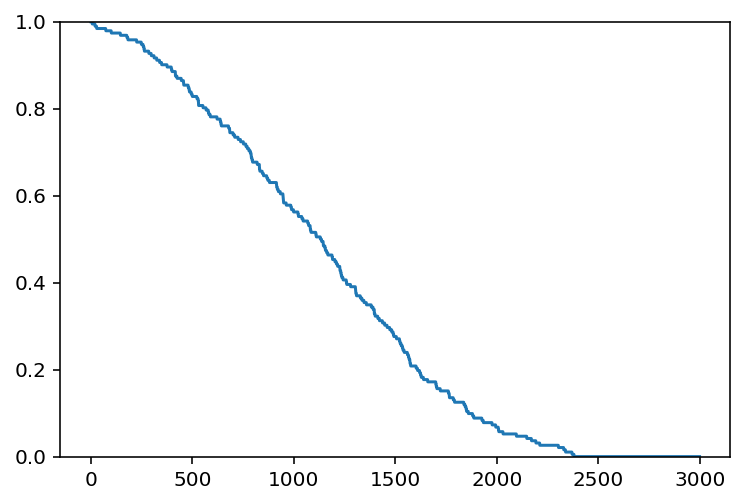

In [130]:
errsPixels[0:100]

965      -21.000000
966      261.460000
967      528.565000
968      790.040000
969      947.010000
970     1144.466000
971     1308.860000
972     1492.503345
973     1624.520000
974     1699.655000
975     1766.070000
976     1886.771200
977     2007.965000
978      642.720000
979      678.710000
980      778.380000
981      832.295000
982      914.325000
983     1084.630000
984     1153.447483
985     1231.960000
986     1413.375000
987     1459.960000
988     1575.280000
989     1721.784206
990     1765.939333
991     1791.286000
992     1848.650000
993     1880.620000
994     1926.155000
           ...     
1035     581.458345
1036     684.603447
1037     751.046723
1038     866.306893
1039     949.506893
1040     998.231723
1041    1080.586723
1042    1136.386723
1043    1209.351723
1044    1227.761723
1045    1279.637551
1046    1396.730068
1047    1537.506893
1048    1602.561723
1049    1701.361723
1050     248.211723
1051     348.026893
1052     494.471723
1053     578.406893


In [89]:
wp

array([[    0,     0],
       [    2,     1],
       [    4,     2],
       ...,
       [21553, 23777],
       [21554, 23778],
       [21555, 23779]])